<a href="https://colab.research.google.com/github/cristinasarakefi-art/TugasAkhirS1/blob/main/Penelitian8Untitled22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score

# Atur tampilan tema grafik agar bersih dan rapi
sns.set_theme(style="whitegrid")
print("Library berhasil diimport")

Library berhasil diimport


In [2]:
# Membaca file dataset (.csv)

nama_file = '/content/Data Fix Penelitian Skripsi KNN.csv'

# Membaca berkas .cvs dengan pemisah titik koma(;) dan desimal koma (,)
df = pd.read_csv(nama_file, sep=';', decimal=',')

print(f"=== SKSES MEMBACA DATASET ===")
print(f"Total Sampel Data Mahasiswa : {df.shape[0]} Baris")
print(f"Total Kolom / Atribut       : {df.shape[1]} Kolom\n")

# Membaca 5 data awal
print("5 data pertama dari dataset:")
display(df.head())

=== SKSES MEMBACA DATASET ===
Total Sampel Data Mahasiswa : 100 Baris
Total Kolom / Atribut       : 9 Kolom

5 data pertama dari dataset:


,Nama Lengkap,Bidang Minat,Norm_IPK Semester 3,Norm_Nilai Matkul DTL,Norm_Nilai Matkul DTT,Norm_Nilai Matkul DPK,Skor Minat TTL,Skor Minat TTT,Skor Minat TKK
0,Kristina Sara Sunia Kefi,Teknik Komputer & Kendali,0.6975,1.0000,0.5000,0.5000,0.2857,0.2857,0.7857
1,Kartini Riyani Boni Geti,Teknik Telekomunikasi,0.6975,0.9375,0.6875,0.5625,0.3571,0.7143,0.6429
2,Fransiska Romana Dua Yustin Nellu,Teknik Telekomunikasi,0.6825,1.0000,0.8125,0.8750,0.8214,1.0000,0.8929
3,JUFRIDSON LAY WOHE,Teknik Komputer & Kendali,0.6200,0.8750,0.6875,0.5000,0.4643,0.0000,0.9286
4,Epin Modjo,Teknik Komputer & Kendali,0.7275,0.8125,0.6875,0.8750,0.7857,0.5000,1.0000


In [3]:
# Pra-Pemrosesan data
# Membersihkan karakter spasi tersembunyi pada nama kelas peminatan
df['Bidang Minat'] = df['Bidang Minat'].astype(str).str.strip()

# Menampilkan sebaran jumlah data asli tiap bidang minat
print("=== Distribusi Kelas Peminatan (TARGET) ===")
print(df['Bidang Minat'].value_counts())

# Menentukan 7 fitur prediktor input (x) dan target luaran (y)
fitur_input = [
    'Norm_IPK Semester 3',
    'Norm_Nilai Matkul DTL',
    'Norm_Nilai Matkul DTT',
    'Norm_Nilai Matkul DPK',
    'Skor Minat TTL',
    'Skor Minat TTT',
    'Skor Minat TKK'
]

X = df[fitur_input]
y = df['Bidang Minat']

=== Distribusi Kelas Peminatan (TARGET) ===
Bidang Minat
Teknik Telekomunikasi        37
Teknik Tenaga Listrik        35
Teknik Komputer & Kendali    28
Name: count, dtype: int64


In [4]:
# 3. PEMBAGIAN DATA MANUALLY BERURUTAN (SAMA DENGAN EXCEL)
# Data Latih : Baris 1 sampai 80 (Indeks 0 hingga 79)
# Data Uji   : Baris 81 sampai 100 (Indeks 80 hingga 99)
X_train = X.iloc[:80]
X_test  = X.iloc[80:]
y_train = y.iloc[:80]
y_test  = y.iloc[80:]

print("=" * 80)
print(f"Jumlah Data Latih (Baris 1 - 80)  : {len(X_train)} Mahasiswa")
print(f"Jumlah Data Uji   (Baris 81 - 100): {len(X_test)} Mahasiswa")
print("=" * 80 + "\n")

Jumlah Data Latih (Baris 1 - 80)  : 80 Mahasiswa
Jumlah Data Uji   (Baris 81 - 100): 20 Mahasiswa



----------------------------------------------------------------------
               HASIL EVALUASI MODEL K-NN UNTUK NILAI K = 3
----------------------------------------------------------------------
Akurasi Sistem : 95.00%

Classification Report:
                           precision    recall  f1-score   support

    Teknik Tenaga Listrik       0.88      1.00      0.93         7
    Teknik Telekomunikasi       1.00      1.00      1.00         6
Teknik Komputer & Kendali       1.00      0.86      0.92         7

                 accuracy                           0.95        20
                macro avg       0.96      0.95      0.95        20
             weighted avg       0.96      0.95      0.95        20



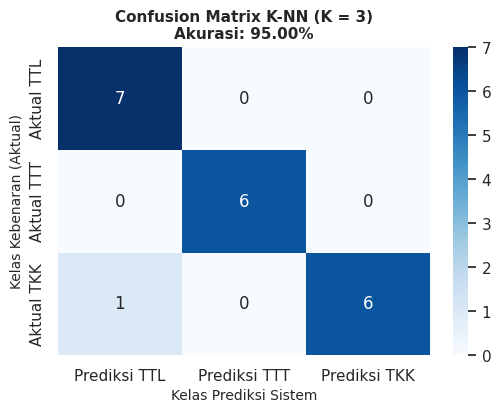

----------------------------------------------------------------------
               HASIL EVALUASI MODEL K-NN UNTUK NILAI K = 5
----------------------------------------------------------------------
Akurasi Sistem : 95.00%

Classification Report:
                           precision    recall  f1-score   support

    Teknik Tenaga Listrik       0.88      1.00      0.93         7
    Teknik Telekomunikasi       1.00      1.00      1.00         6
Teknik Komputer & Kendali       1.00      0.86      0.92         7

                 accuracy                           0.95        20
                macro avg       0.96      0.95      0.95        20
             weighted avg       0.96      0.95      0.95        20



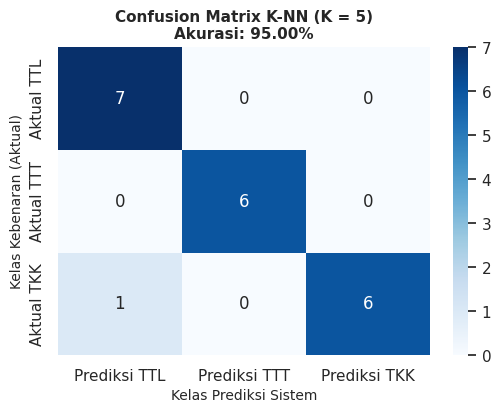

----------------------------------------------------------------------
               HASIL EVALUASI MODEL K-NN UNTUK NILAI K = 7
----------------------------------------------------------------------
Akurasi Sistem : 95.00%

Classification Report:
                           precision    recall  f1-score   support

    Teknik Tenaga Listrik       0.88      1.00      0.93         7
    Teknik Telekomunikasi       1.00      1.00      1.00         6
Teknik Komputer & Kendali       1.00      0.86      0.92         7

                 accuracy                           0.95        20
                macro avg       0.96      0.95      0.95        20
             weighted avg       0.96      0.95      0.95        20



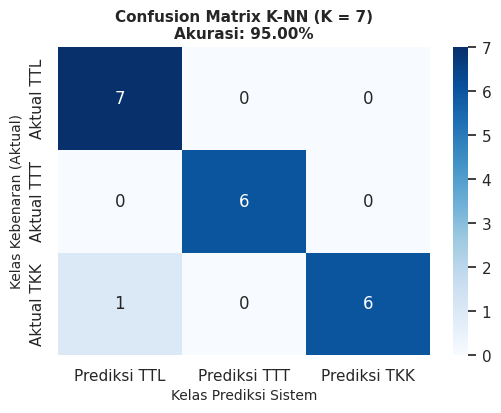

----------------------------------------------------------------------
               HASIL EVALUASI MODEL K-NN UNTUK NILAI K = 9
----------------------------------------------------------------------
Akurasi Sistem : 90.00%

Classification Report:
                           precision    recall  f1-score   support

    Teknik Tenaga Listrik       0.78      1.00      0.88         7
    Teknik Telekomunikasi       1.00      1.00      1.00         6
Teknik Komputer & Kendali       1.00      0.71      0.83         7

                 accuracy                           0.90        20
                macro avg       0.93      0.90      0.90        20
             weighted avg       0.92      0.90      0.90        20



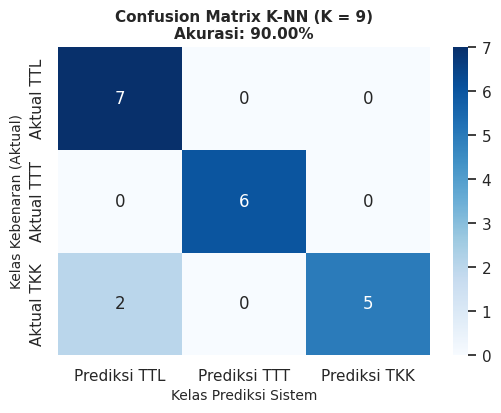

----------------------------------------------------------------------
               HASIL EVALUASI MODEL K-NN UNTUK NILAI K = 11
----------------------------------------------------------------------
Akurasi Sistem : 90.00%

Classification Report:
                           precision    recall  f1-score   support

    Teknik Tenaga Listrik       0.78      1.00      0.88         7
    Teknik Telekomunikasi       1.00      1.00      1.00         6
Teknik Komputer & Kendali       1.00      0.71      0.83         7

                 accuracy                           0.90        20
                macro avg       0.93      0.90      0.90        20
             weighted avg       0.92      0.90      0.90        20



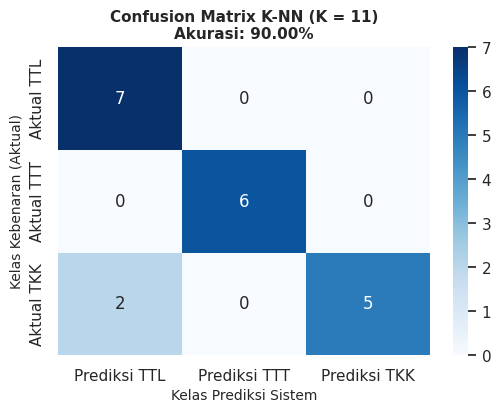


TABEL REKAPITULASI HASIL VARIASI NILAI K (PEMBAGIAN BERURUTAN)


,Nilai K,Akurasi Colab (%),Prediksi Benar
0,K = 3,95.00%,19 / 20 Data
1,K = 5,95.00%,19 / 20 Data
2,K = 7,95.00%,19 / 20 Data
3,K = 9,90.00%,18 / 20 Data
4,K = 11,90.00%,18 / 20 Data


In [5]:
# 4. KLASIFIKASI K-NN DAN PERHITUNGAN AKURASI SESUAI EXCEL
label_kelas = ['Teknik Tenaga Listrik', 'Teknik Telekomunikasi', 'Teknik Komputer & Kendali']
variasi_k = [3, 5, 7, 9, 11]
rekap_performa = []

for k in variasi_k:
    # A. Inisialisasi Model K-NN (Euclidean Distance)
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')

    # B. Pelatihan Model
    knn.fit(X_train, y_train)

    # C. Prediksi Data Uji
    y_pred = knn.predict(X_test)

    # D. Hitung Akurasi Keseluruhan
    acc = accuracy_score(y_test, y_pred) * 100
    cm = confusion_matrix(y_test, y_pred, labels=label_kelas)

    rekap_performa.append({
        'Nilai K': f"K = {k}",
        'Akurasi Colab (%)': f"{acc:.2f}%",
        'Prediksi Benar': f"{np.trace(cm)} / {len(y_test)} Data"
    })

    print("-" * 70)
    print(f"               HASIL EVALUASI MODEL K-NN UNTUK NILAI K = {k}")
    print("-" * 70)
    print(f"Akurasi Sistem : {acc:.2f}%\n")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, labels=label_kelas, zero_division=0))

    # Visualisasi Heatmap Confusion Matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Prediksi TTL', 'Prediksi TTT', 'Prediksi TKK'],
                yticklabels=['Aktual TTL', 'Aktual TTT', 'Aktual TKK'])

    plt.title(f'Confusion Matrix K-NN (K = {k})\nAkurasi: {acc:.2f}%', fontsize=11, fontweight='bold')
    plt.ylabel('Kelas Kebenaran (Aktual)', fontsize=10)
    plt.xlabel('Kelas Prediksi Sistem', fontsize=10)

    nama_gambar = f'confusion_matrix_urut_K_{k}.png'
    plt.savefig(nama_gambar, dpi=300, bbox_inches='tight')
    plt.show()

# 5. Tabel Ringkasan Hasil
print("\n" + "=" * 80)
print("TABEL REKAPITULASI HASIL VARIASI NILAI K (PEMBAGIAN BERURUTAN)")
print("=" * 80)
display(pd.DataFrame(rekap_performa))

/tmp/ipykernel_1694/1407424680.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


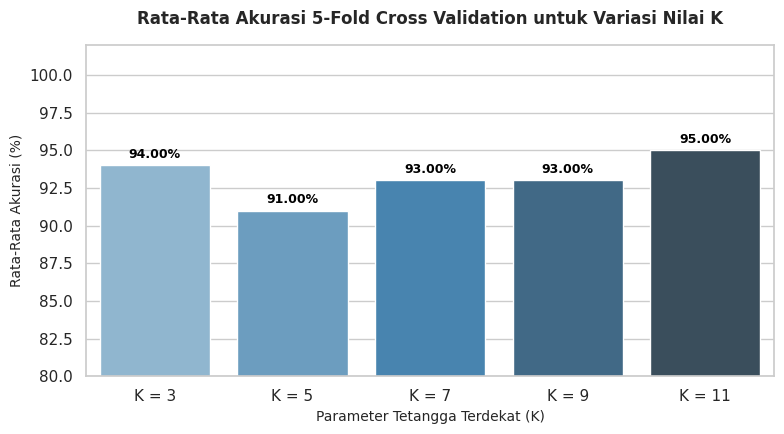

In [6]:
# Pengujian K-Fold Cross Validation (5-Fold)
# Menghitung Rata-Rata Akurasi 5-Fold Cross Validation untuk Setiap Nilai K
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
variasi_k = [3, 5, 7, 9, 11]

rata_rata_cv = []
for k in variasi_k:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    scores = cross_val_score(knn, X, y, cv=skf)
    rata_rata_cv.append({
        'Nilai K': f'K = {k}',
        'Rata-Rata Akurasi': scores.mean() * 100
    })

df_mean = pd.DataFrame(rata_rata_cv)

# Membuat Plot Visualisasi 5 Batang
plt.figure(figsize=(8, 4.5))
ax = sns.barplot(
    data=df_mean,
    x='Nilai K',
    y='Rata-Rata Akurasi',
    palette='Blues_d'
)

plt.title('Rata-Rata Akurasi 5-Fold Cross Validation untuk Variasi Nilai K', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Parameter Tetangga Terdekat (K)', fontsize=10)
plt.ylabel('Rata-Rata Akurasi (%)', fontsize=10)
plt.ylim(80, 102)

# Menambahkan angka persentase di atas setiap batang
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}%',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=9, fontweight='bold', color='black',
                xytext=(0, 3),
                textcoords='offset points')

plt.tight_layout()
# Simpan gambar otomatis format PNG 300 DPI
plt.savefig('grafik_5_batang_cross_validation.png', dpi=300, bbox_inches='tight')
plt.show()